## Hi! Here is the new playground, go ahead and explore the dataset and find out as many insights as you can before jumping to the ML part! 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('./dataset/housing.csv')
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 20640
Number of columns: 10


In [5]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

## Dataset Overview

The dataset contains 20,640 observations (rows) and 10 features describing
geographical, demographic and economic characteristics of housing areas
in California (columns).

The target variable is median_house_value, which represents the median
house value recorded for each area.

## Dataset Column Description

The dataset contains geographical, demographic and economic information about housing areas in California. Each row represents a geographical area rather than a single house.

### `longitude`

* Represents the geographical longitude of the housing area.
* Longitude indicates the east–west position of the area.
* More negative values generally represent locations farther west.
* This feature can help identify areas located closer to the California coast.

### `latitude`

* Represents the geographical latitude of the housing area.
* Latitude indicates the north–south position of the area.
* Higher values represent locations farther north.
* Together with longitude, this feature describes the geographical location of each housing area.

### `housing_median_age`

* Represents the median age of the houses located in the area.
* It does not represent the age of one individual house.
* A higher value means that the houses in that area are generally older.
* The maximum value of 52 may indicate that the feature was capped at an upper limit.

### `total_rooms`

* Represents the total number of rooms in all houses from the geographical area.
* It does not represent the number of rooms in a single house.
* Areas containing more households generally also have a larger number of total rooms.
* This feature may become more informative when divided by the number of households.

### `total_bedrooms`

* Represents the total number of bedrooms in all houses from the area.
* This is the only original feature containing missing values in the dataset.
* The missing observations can be replaced with the median value during data preprocessing.
* This feature is strongly related to `total_rooms`.

### `population`

* Represents the total number of people living in the geographical area.
* It describes the size of the local population.
* A large population does not necessarily indicate expensive housing.
* The feature may be more informative when divided by the number of households.

### `households`

* Represents the total number of households located in the area.
* A household usually refers to a group of people living in the same housing unit.
* This feature helps describe the size of the geographical area.
* It can be used to calculate average values per household.

### `median_income`

* Represents the median income of households in the area.
* The values are expressed in tens of thousands of dollars.
* For example, a value of `4.5` represents a median income of approximately **45,000 dollars**.
* This feature has one of the strongest relationships with the median house value.
* Areas with higher median income generally tend to have more expensive houses.

### `ocean_proximity`

* Represents the position of the housing area relative to the ocean.
* It is the only categorical feature in the original dataset.
* Its possible categories include:

  * `<1H OCEAN` – located less than one hour from the ocean;
  * `INLAND` – located in an inland area;
  * `NEAR OCEAN` – located near the ocean;
  * `NEAR BAY` – located near a bay;
  * `ISLAND` – located on an island.
* Coastal areas generally have higher house values than inland areas.
* This feature must be encoded before it can be used by most machine-learning models.

### `median_house_value`

* Represents the median value of houses in the geographical area.
* It represents the median house value in the area, not the value of one individual house.
* The maximum recorded value is `500001'.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Conclusions

- The dataset contains 20,640 observations for most numerical features.
- The `total_bedrooms` column contains only 20,433 values, confirming that it has missing data.
- The average median house value is approximately 206,856, while the median is 179,700. This suggests that the target distribution is right-skewed, with some expensive areas increasing the average.
- The maximum value of `median_house_value` is 500,001, which may indicate that this feature was capped at an upper limit.
- The maximum value of `housing_median_age` is 52, which may also indicate an upper limit.
- Features such as `total_rooms`, `total_bedrooms`, `population`, and `households` have maximum values much larger than their third quartile, suggesting right-skewed distributions and possible extreme values.
- The numerical features have very different scales, which may require feature scaling for some Machine Learning models.

In [8]:
house_value_max = df["median_house_value"].max()
house_value_max_count = (
    df["median_house_value"] == house_value_max
).sum()

age_max = df["housing_median_age"].max()
age_max_count = (
    df["housing_median_age"] == age_max
).sum()

print("Maximum median house value:", house_value_max)
print("Rows at maximum house value:", house_value_max_count)
print(
    "Percentage at maximum house value:",
    round(house_value_max_count / len(df) * 100, 2),
    "%"
)

print()

print("Maximum housing median age:", age_max)
print("Rows at maximum housing age:", age_max_count)
print(
    "Percentage at maximum housing age:",
    round(age_max_count / len(df) * 100, 2),
    "%"
)

Maximum median house value: 500001.0
Rows at maximum house value: 965
Percentage at maximum house value: 4.68 %

Maximum housing median age: 52.0
Rows at maximum housing age: 1273
Percentage at maximum housing age: 6.17 %


## Conclusions

- `median_house_value` reaches a maximum value of 500,001 for 965 observations, representing 4.68% of the dataset.
- `housing_median_age` reaches a maximum value of 52 for 1,273 observations, representing 6.17% of the dataset.
- The large number of observations located exactly at these maximum values indicates that both features were likely capped.
- For `median_house_value`, the real values of some districts may be higher than 500,001, but the dataset does not distinguish between them.
- This limitation may affect the model, especially when predicting expensive districts.
- These observations will not be removed at this stage, but the limitation should be considered when evaluating the model.

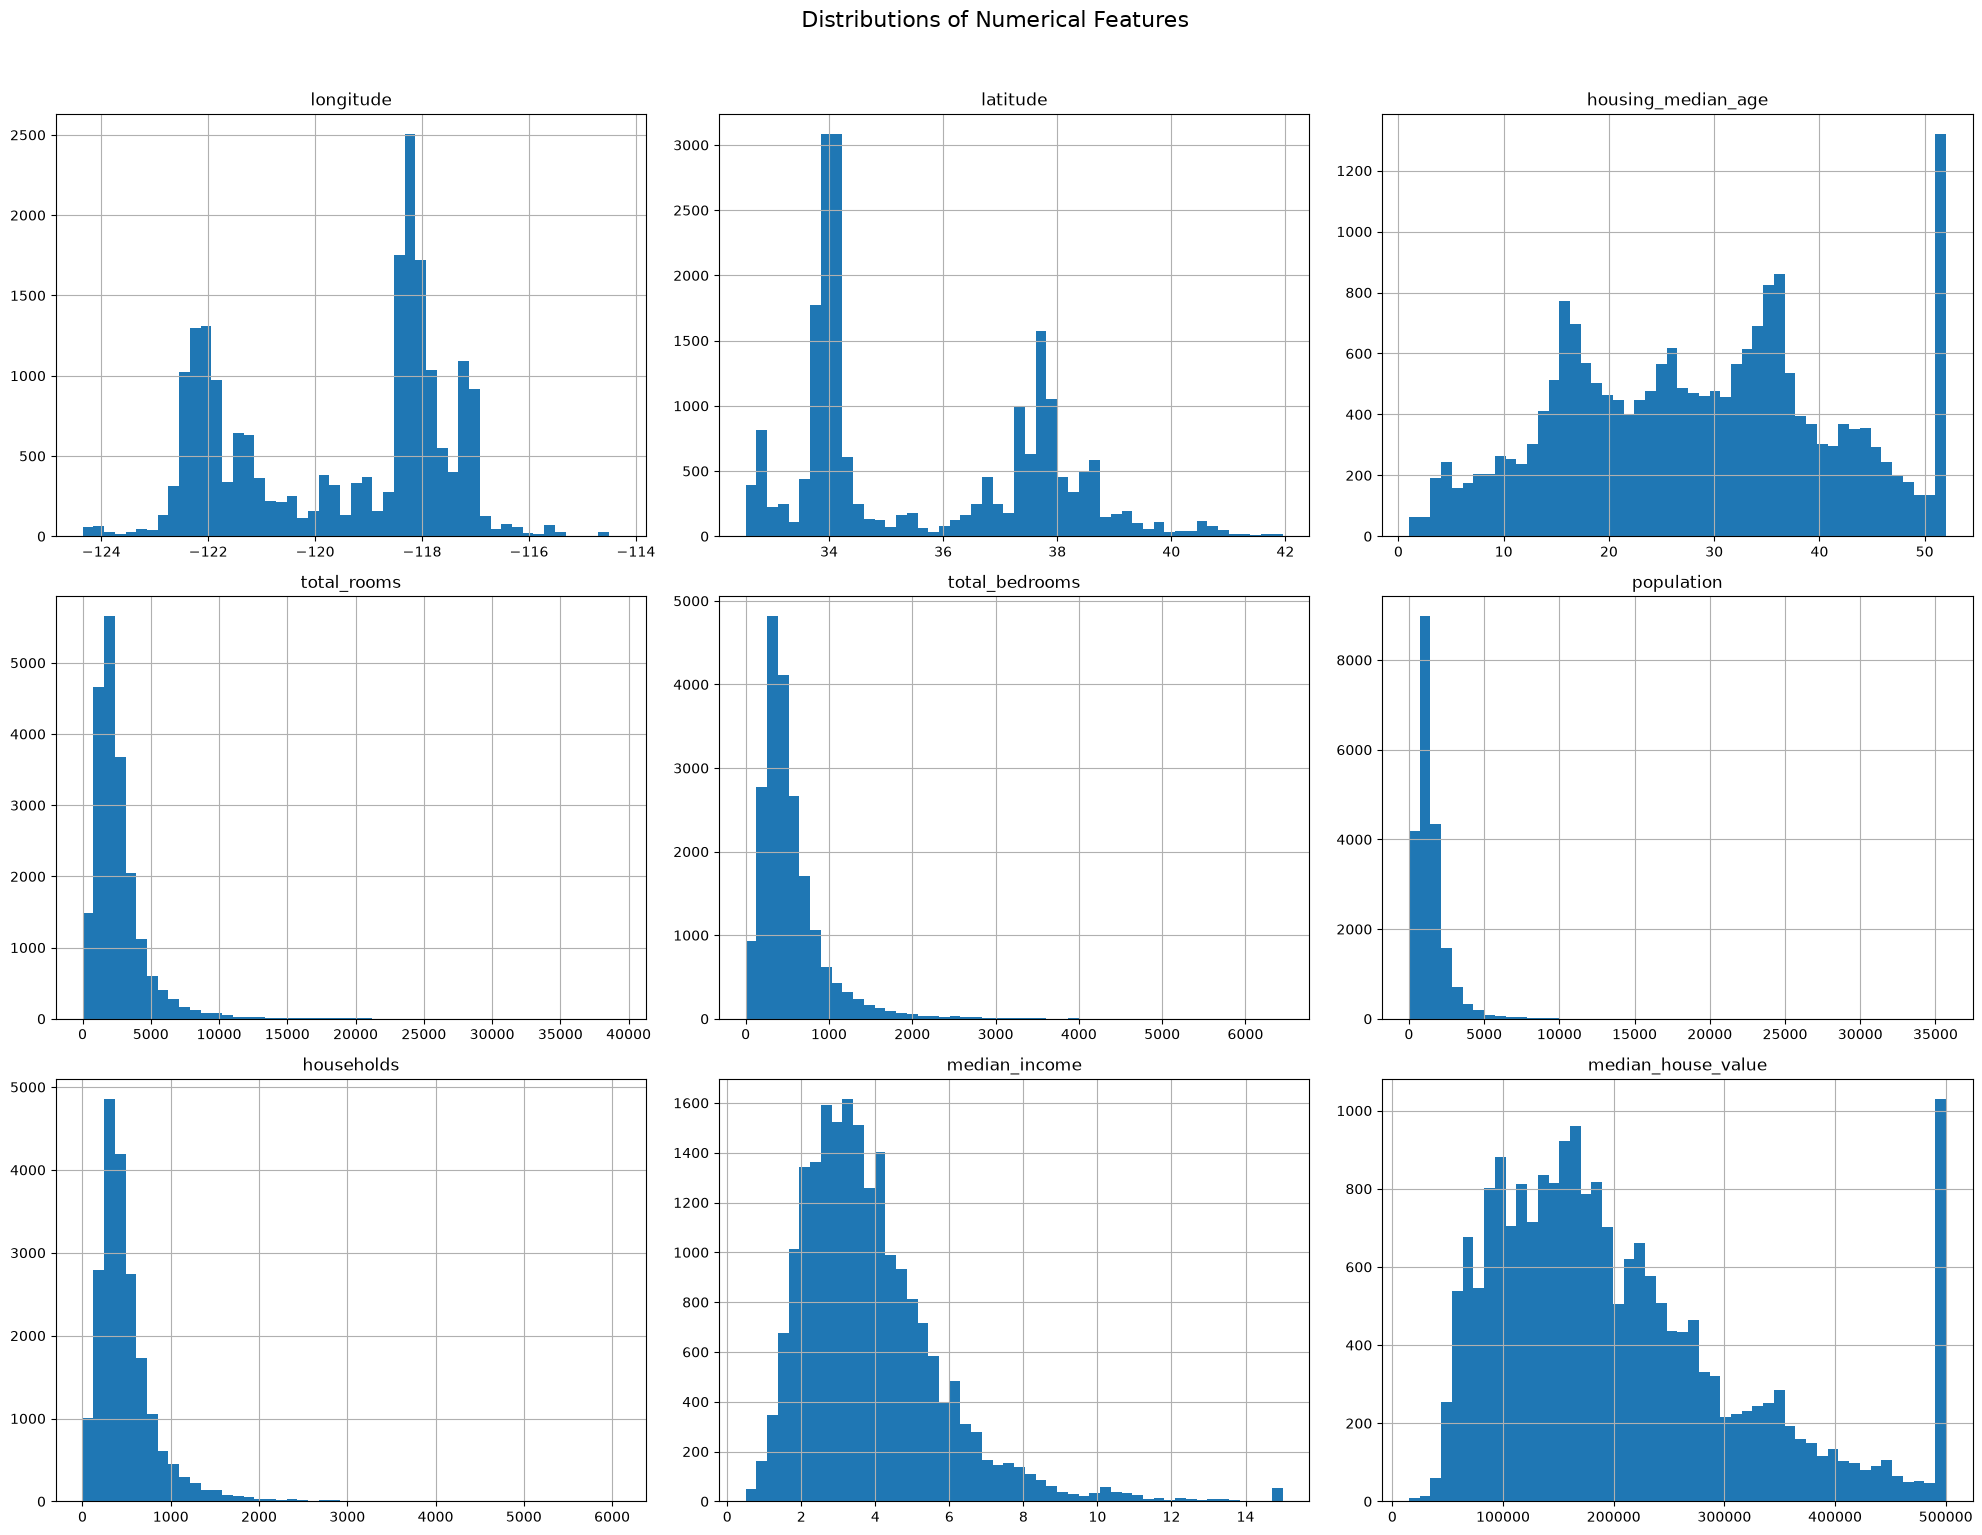

In [9]:
df.hist(
    bins=50,
    figsize=(20, 15)
)

plt.suptitle(
    "Distributions of Numerical Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

## Conclusions

- The geographical features, `longitude` and `latitude`, have irregular and multimodal distributions because the observations are concentrated in specific regions of California.
- `housing_median_age` has a large concentration at the maximum value of 52, suggesting that this feature was capped.
- `total_rooms`, `total_bedrooms`, `population`, and `households` are strongly right-skewed. Most districts have relatively small values, while a few districts have very large values.
- `median_income` is also right-skewed, and the value near 15 appears to be an upper limit.
- `median_house_value` is right-skewed and presents a clear spike at approximately 500,000, suggesting that the target variable was capped.

In [10]:
duplicate_rows = df.duplicated().sum()

print("Number of duplicated rows:", duplicate_rows)

Number of duplicated rows: 0


- The dataset does not contain duplicated observations, so no rows need
  to be removed because of complete duplication.

In [11]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

total_bedrooms    207
dtype: int64

In [12]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_percentage

total_bedrooms        1.002907
longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

In [13]:
missing_bedrooms_percentage = (
    df["total_bedrooms"].isnull().mean() * 100
)

print(
    f"Missing total_bedrooms values: "
    f"{missing_bedrooms_percentage:.2f}%"
)

Missing total_bedrooms values: 1.00%


In [14]:
df_eda = df.copy()

In [15]:
bedrooms_median = df_eda["total_bedrooms"].median()

df_eda["total_bedrooms"] = (
    df_eda["total_bedrooms"].fillna(bedrooms_median)
)

print("Median used:", bedrooms_median)
print(df_eda.isnull().sum())

Median used: 435.0
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


## Conclusions

- `total_bedrooms` is the only feature containing missing values.
  
- It contains 207 missing observations, representing approximately 1%
  of the complete dataset.

- Since the percentage is relatively small, the observations do not
  need to be removed.

- The missing values were replaced with the median number of bedrooms.

- The median was selected because it is less sensitive to extreme
  values than the arithmetic mean.

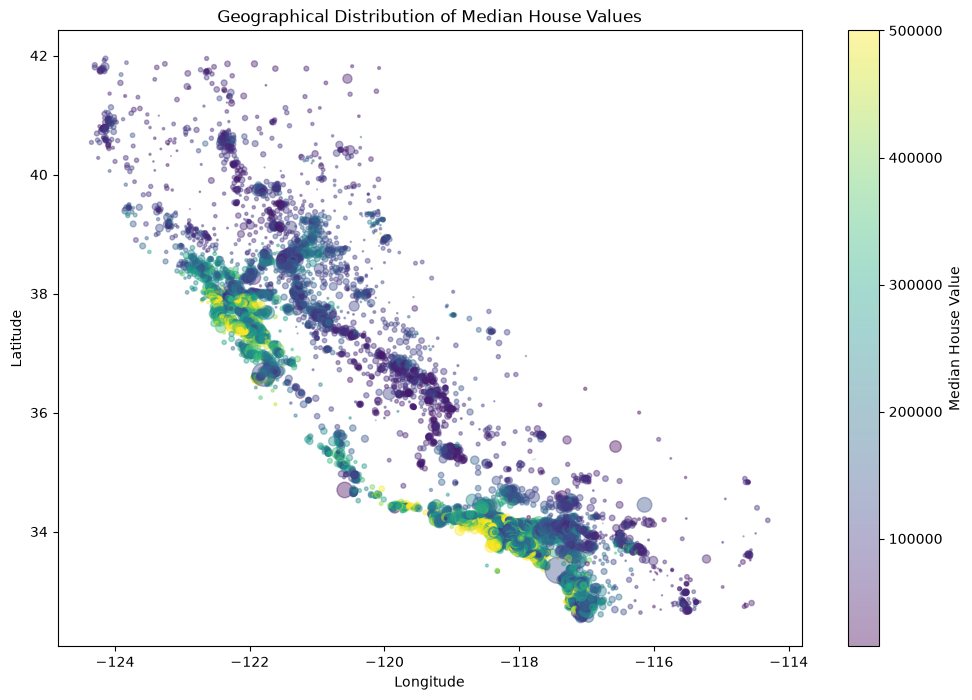

In [16]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    df_eda["longitude"],
    df_eda["latitude"],
    s=df_eda["population"] / 100,
    c=df_eda["median_house_value"],
    alpha=0.4,
    cmap="viridis"
)

plt.colorbar(scatter, label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Median House Values")
plt.show()

## Conclusions

- The observations follow the geographical shape of California, confirming that longitude and latitude contain meaningful spatial information.
- Districts located near the coast generally have higher median house values than inland districts.
- Several clusters of high house values can be observed around densely populated coastal areas.
- Inland and northern regions generally contain lower house values.
- The size of each point represents the district population, while the color represents the median house value.
- Longitude and latitude may have weak individual correlations with the target, but together they provide important information about location.

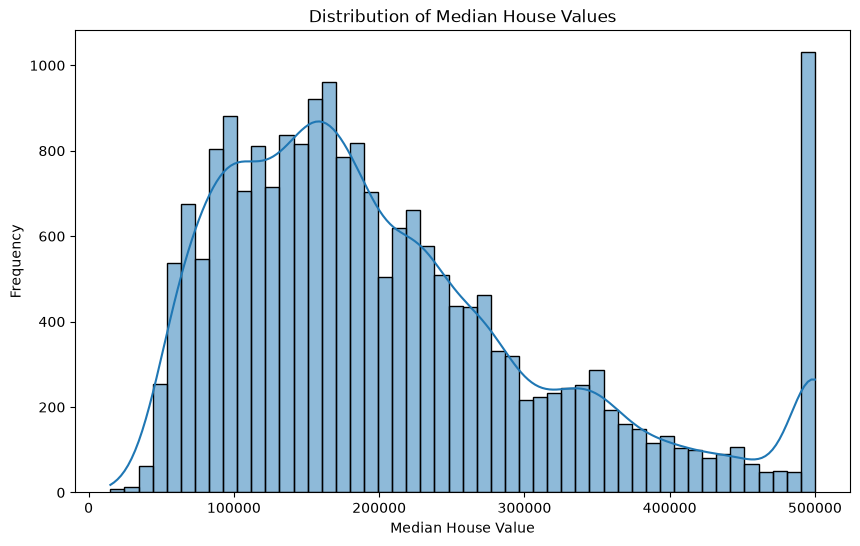

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_eda,
    x="median_house_value",
    bins=50,
    kde=True
)

plt.title("Distribution of Median House Values")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

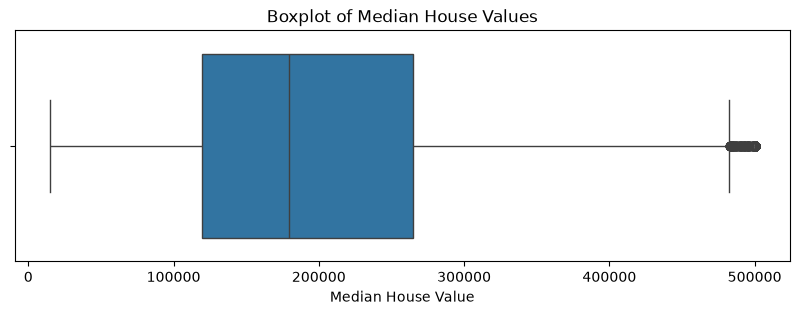

In [18]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df_eda,
    x="median_house_value"
)

plt.title("Boxplot of Median House Values")
plt.xlabel("Median House Value")
plt.show()

## Conclusions

- The mean house value is higher than the median, which confirms the
  influence of expensive housing areas.

- This suggests that the target variable may have been capped at an
  upper limit.

- The real values of these observations may be higher than the recorded
  value.

In [19]:
ocean_counts = (
    df_eda["ocean_proximity"]
    .value_counts()
)

ocean_counts

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

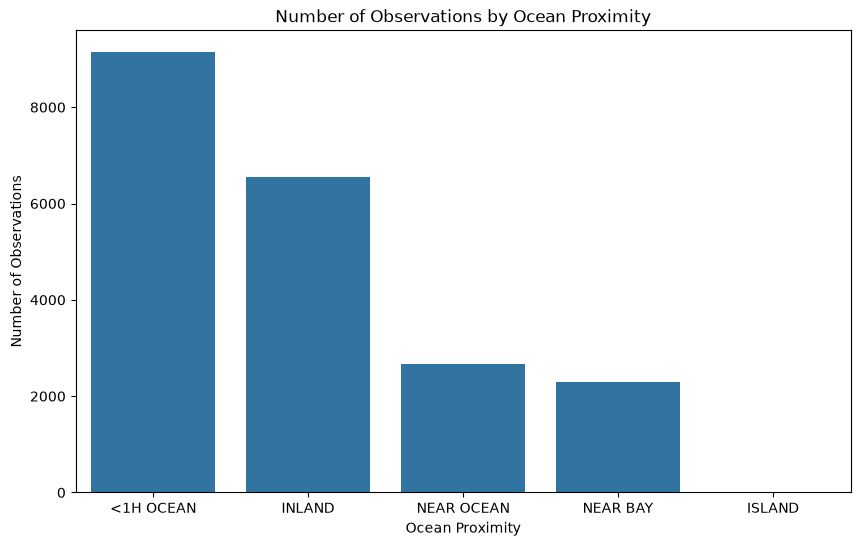

In [20]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_eda,
    x="ocean_proximity",
    order=ocean_counts.index
)

plt.title("Number of Observations by Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Number of Observations")
plt.show()

In [21]:
ocean_percentage = (
    df_eda["ocean_proximity"]
    .value_counts(normalize=True)
    .mul(100)
)

ocean_percentage

ocean_proximity
<1H OCEAN     44.263566
INLAND        31.739341
NEAR OCEAN    12.877907
NEAR BAY      11.094961
ISLAND         0.024225
Name: proportion, dtype: float64

In [22]:
ocean_price_statistics = (
    df_eda
    .groupby("ocean_proximity")["median_house_value"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

ocean_price_statistics

,count,mean,median,min,max
ocean_proximity,,,,,
ISLAND,5,380440.000000,414700.0,287500.0,450000.0
NEAR BAY,2290,259212.311790,233800.0,22500.0,500001.0
NEAR OCEAN,2658,249433.977427,229450.0,22500.0,500001.0
<1H OCEAN,9136,240084.285464,214850.0,17500.0,500001.0
INLAND,6551,124805.392001,108500.0,14999.0,500001.0


## Conclusions on Ocean Proximity

- The `<1H OCEAN` category contains the largest number of observations, representing approximately **44%** of the dataset.

- The `INLAND` category is the second-largest group, representing approximately **32%** of the observations.

- The `ISLAND` category contains only **5 observations**, so its statistical results are not representative and should be interpreted carefully.

- The distribution of observations across the ocean-proximity categories is unbalanced.

- The `ISLAND` category has the highest average house value, but this result is unreliable because of the very small number of observations.

- Among the well-represented categories, houses located `NEAR BAY` and `NEAR OCEAN` have the highest average values.

- The `INLAND` category has the lowest average house value, showing that inland houses are generally cheaper than houses located closer to the coast.

- Overall, ocean proximity appears to be an important feature for house value, although it should be interpreted together with median income, geographical location and housing characteristics.


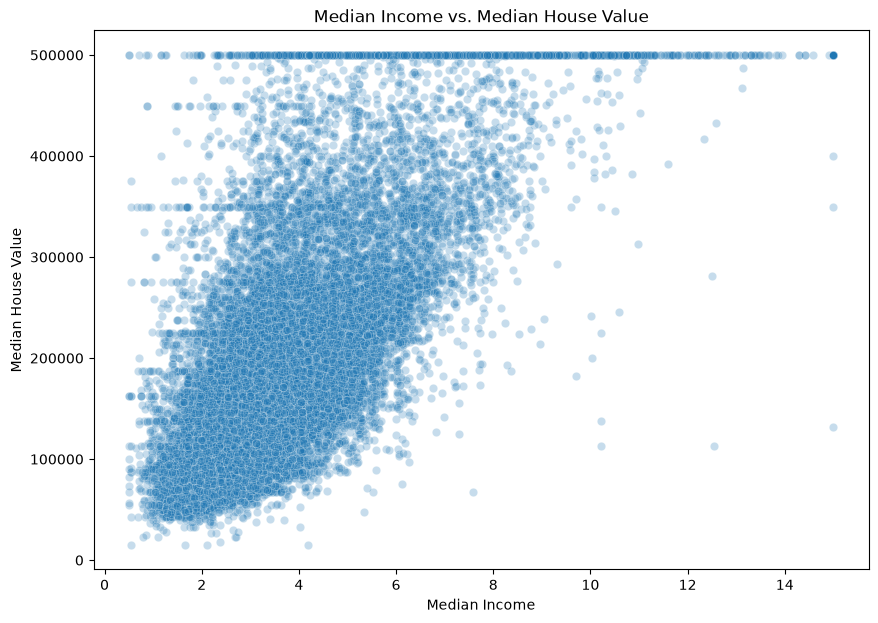

In [23]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_eda,
    x="median_income",
    y="median_house_value",
    alpha=0.25
)

plt.title("Median Income vs. Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

## Conclusions on Median Income vs. Median House Value

- There is a clear positive relationship between median income and median house value.

- As the median income of an area increases, the median house value generally increases as well.

- Areas with low median income are mainly concentrated in the lower and medium house-value ranges.

- Areas with high median income generally have more expensive houses, although some variation can still be observed.

- Median income appears to be one of the most important numerical features for estimating house value.

- Median income alone cannot completely determine house value because geographical location, ocean proximity, housing age and household characteristics also influence the price.

- Overall, the graph suggests a strong association between the economic level of an area and its housing prices, but this relationship does not prove direct causation.

For easier interpretation, the continuous median income feature is divided
into five manually defined income categories. These categories are created
only for exploratory analysis.

In [24]:
df_eda["income_category"] = pd.cut(
    df_eda["median_income"],
    bins=[0, 2, 4, 6, 8, np.inf],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [25]:
income_category_stats = (
    df_eda
    .groupby(
        "income_category",
        observed=False
    )["median_house_value"]
    .agg(["count", "mean", "median"])
)

income_category_stats

,count,mean,median
income_category,,,
Very Low,2457,112497.156695,93300.0
Low,10096,168199.345880,153100.0
Medium,5725,244635.195284,226800.0
High,1672,344844.687201,335900.0
Very High,690,460639.334783,500001.0


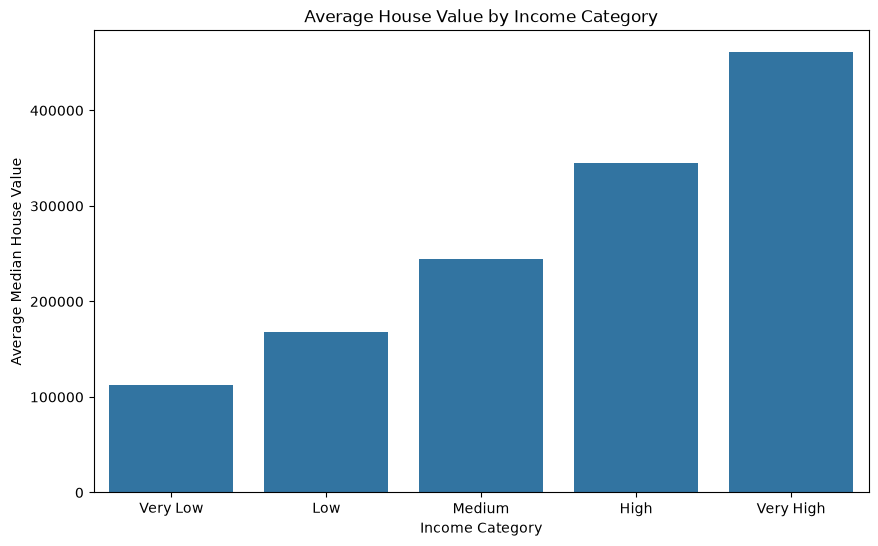

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_eda,
    x="income_category",
    y="median_house_value",
    errorbar=None
)

plt.title("Average House Value by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Average Median House Value")
plt.show()

## Conclusions on Average House Value by Income Category

- The average house value increases progressively from the `Very Low` income category to the `Very High` income category.

- Areas classified as `Very Low` or `Low` income generally have the lowest average house values.

- Areas with `Medium` income have noticeably higher average house values than the lower-income categories.

- The `High` and `Very High` income categories contain the most expensive housing areas on average.

- The difference between the categories confirms the positive relationship previously observed between median income and median house value.

- Grouping income values into categories makes the general trend easier to interpret than the scatterplot, although it removes some individual variation.

- Overall, income category appears to be a useful feature for describing differences in house values, but location and other housing characteristics must also be considered.


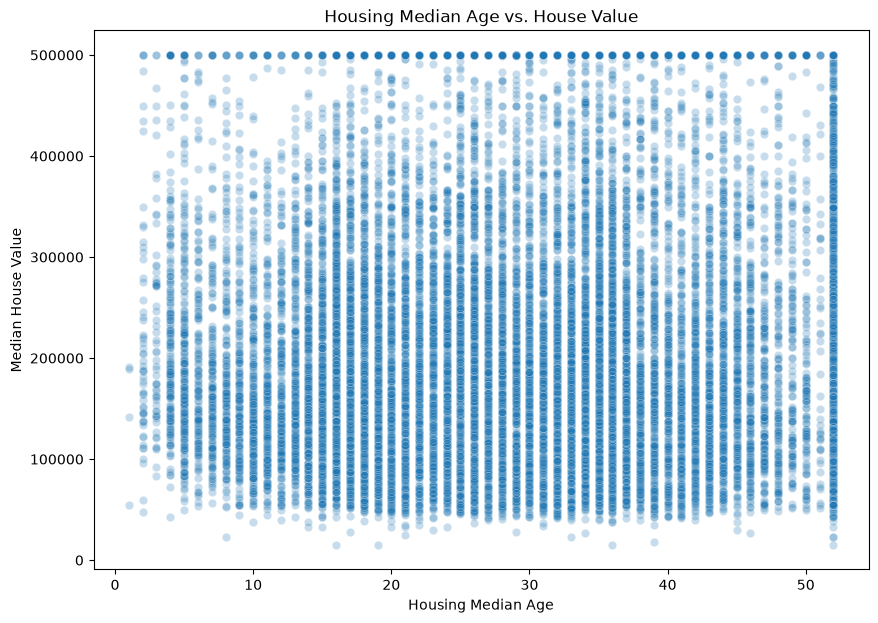

In [27]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_eda,
    x="housing_median_age",
    y="median_house_value",
    alpha=0.25
)

plt.title("Housing Median Age vs. House Value")
plt.xlabel("Housing Median Age")
plt.ylabel("Median House Value")
plt.show()

## Conclusions on Housing Median Age vs. House Value

- There is no clear strong relationship between housing median age and median house value.

- Houses from areas with the same median age can have considerably different values.

- Older housing areas are not necessarily cheaper than newer housing areas.

- Some older areas may still have high house values because they are located near the ocean, close to important cities or in areas with high median income.

- The vertical concentration of observations at a housing median age of **52 years** suggests that this feature may have been capped at an upper limit.

- Housing median age may provide useful information for predicting house value, but it cannot determine the price by itself.

- Overall, geographical location, ocean proximity and median income appear to have a stronger influence on house value than housing age alone.


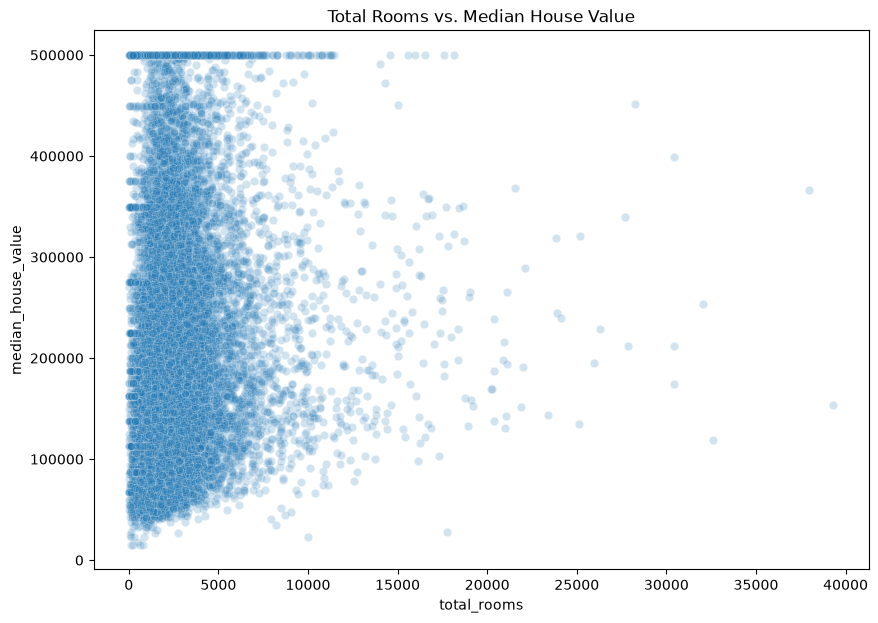

In [28]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_eda,
    x="total_rooms",
    y="median_house_value",
    alpha=0.2
)

plt.title("Total Rooms vs. Median House Value")
plt.show()

## Conclusions on Total Rooms vs. Median House Value

- There is a weak positive relationship between the total number of rooms and the median house value.

- Areas with more total rooms may have higher house values, but the relationship is not sufficiently strong or consistent.

- Most observations are concentrated in areas with a relatively low or medium number of total rooms.

- Areas with a similar number of total rooms can have considerably different house values.

- Some areas contain an unusually large number of rooms and may represent large districts rather than data errors.

- The `total_rooms` feature cannot describe the size of an individual house because it represents the total number of rooms in the entire area.

- A derived feature such as `rooms_per_household` may be more informative because it considers both the total number of rooms and the number of households in the area.


In [29]:
df_eda["rooms_per_household"] = (
    df_eda["total_rooms"] / df_eda["households"]
)

df_eda["bedrooms_per_room"] = (
    df["total_bedrooms"] / df["total_rooms"]
)

df_eda["population_per_household"] = (
    df_eda["population"] / df_eda["households"]
)

df_eda[
    [
        "rooms_per_household",
        "bedrooms_per_room",
        "population_per_household"
    ]
].describe()

,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20433.000000,20640.000000
mean,5.429000,0.213039,3.070655
std,2.474173,0.057983,10.386050
min,0.846154,0.100000,0.692308
25%,4.440716,0.175427,2.429741
50%,5.229129,0.203162,2.818116
75%,6.052381,0.239821,3.282261
max,141.909091,1.000000,1243.333333


## Conclusions

- A typical district contains approximately 5.23 rooms per household.
- Bedrooms represent approximately 20% of the total number of rooms in a typical district.
- A typical household contains approximately 2.82 people.
- `rooms_per_household` and `population_per_household` contain a few very large values compared with their third quartiles.
- Because of these extreme observations, the median is more representative than the mean for these features.
- The engineered features provide more meaningful information than the original aggregated totals.
- Extreme values will not be removed at this stage, but their influence should be considered during model evaluation.

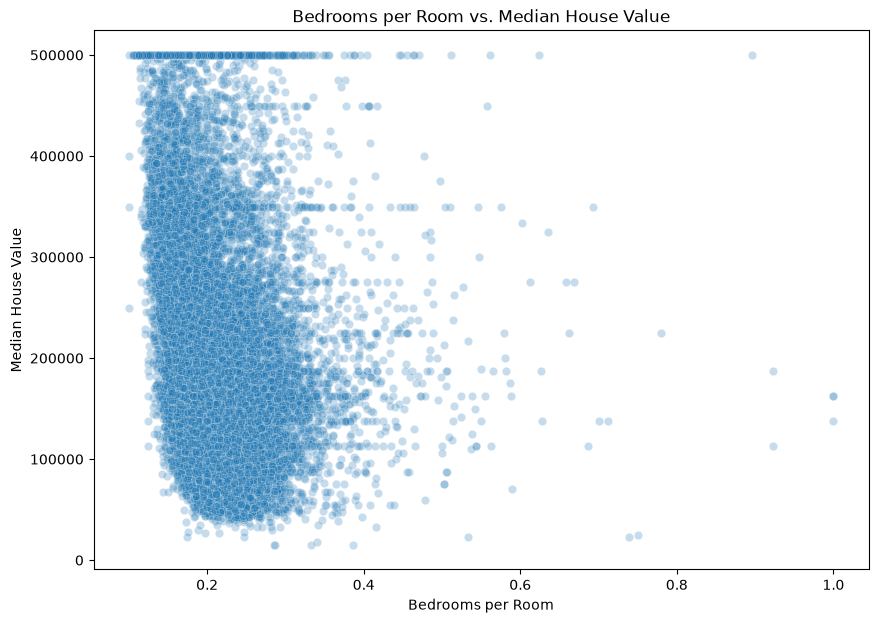

In [30]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_eda,
    x="bedrooms_per_room",
    y="median_house_value",
    alpha=0.25
)

plt.title("Bedrooms per Room vs. Median House Value")
plt.xlabel("Bedrooms per Room")
plt.ylabel("Median House Value")
plt.show()

## Conclusions

- A higher proportion of bedrooms relative to the total number of rooms is generally associated with lower median house values.
- The relationship is not perfectly linear, but it confirms the negative correlation observed in the correlation matrix.
- This engineered feature appears to be more informative than the original `total_bedrooms` feature.

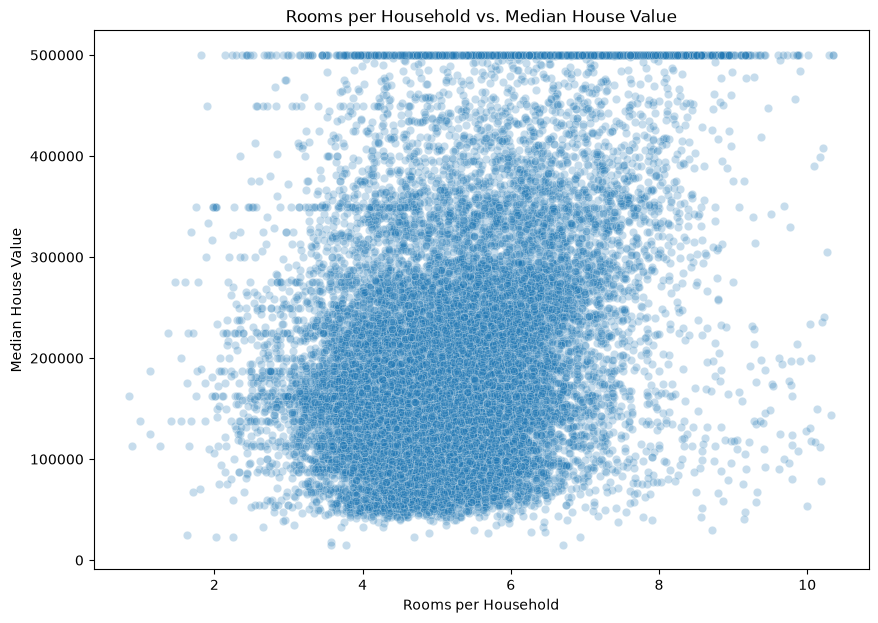

In [31]:
rooms_limit = df_eda["rooms_per_household"].quantile(0.99)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_eda[df_eda["rooms_per_household"] <= rooms_limit],
    x="rooms_per_household",
    y="median_house_value",
    alpha=0.25
)

plt.title("Rooms per Household vs. Median House Value")
plt.xlabel("Rooms per Household")
plt.ylabel("Median House Value")
plt.show()

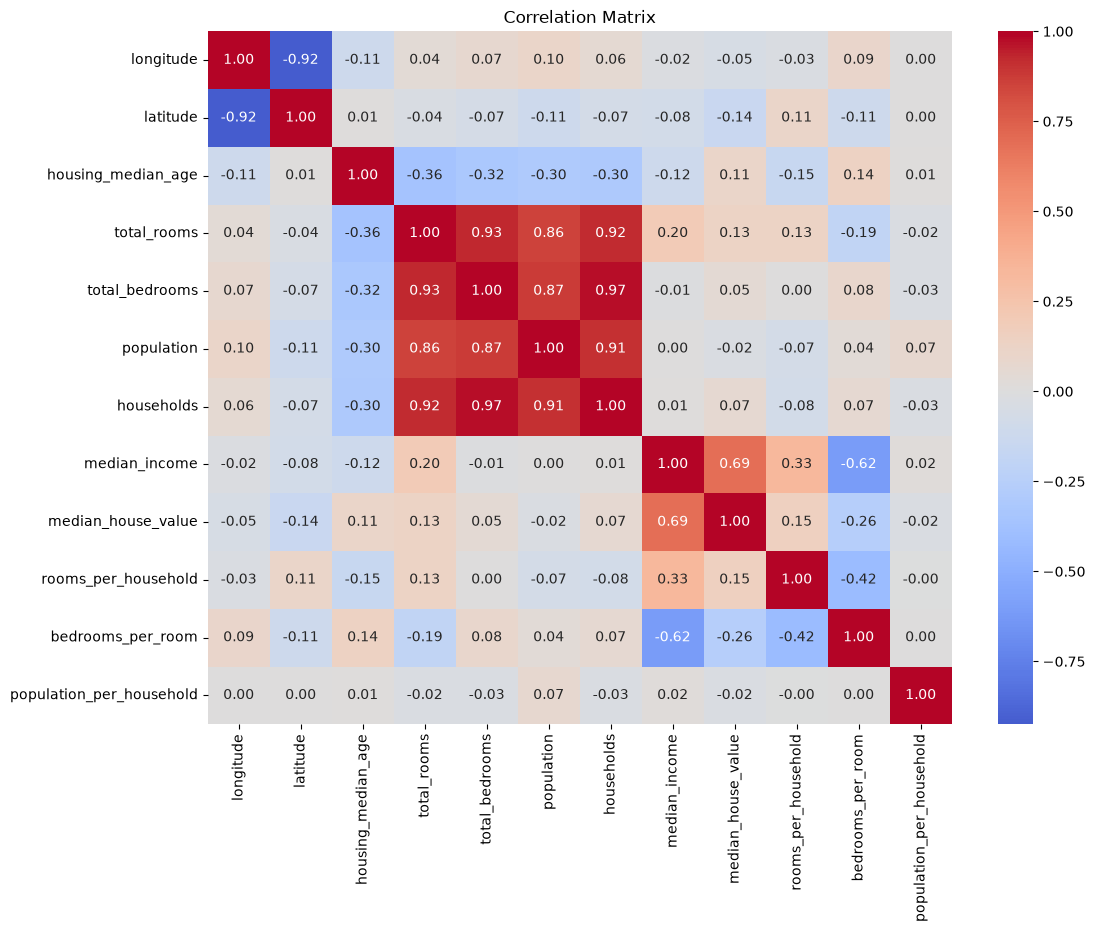

In [32]:
numeric_df = df_eda.select_dtypes(
    include=["int64", "float64"]
)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

## Conclusions

- `median_income` has the strongest positive correlation with `median_house_value`, approximately 0.69. Districts with higher median incomes generally have higher house values.
- `bedrooms_per_room` has a moderate negative correlation with the target, approximately -0.26. A higher proportion of bedrooms relative to the total number of rooms is generally associated with lower house values.
- `rooms_per_household` has a weak positive correlation with the target, approximately 0.15.
- `population_per_household` has almost no linear correlation with the target, approximately -0.02.
- The engineered feature `bedrooms_per_room` is more informative than the original `total_bedrooms` feature, whose correlation with the target is only approximately 0.05.
- `total_rooms`, `total_bedrooms`, `population`, and `households` are strongly correlated with one another, with correlations between approximately 0.86 and 0.97. These features contain partially redundant information.
- Longitude and latitude have weak individual linear correlations with house value, but the geographical visualization showed that their combination contains important spatial information.
- Correlation only measures linear relationships, so features with weak correlations may still be useful for nonlinear Machine Learning models.

# Train-Test Split

In [33]:
from sklearn.model_selection import train_test_split

df_model = df.copy()

df_model["income_category"] = pd.cut(
    df_model["median_income"],
    bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5]
)

train_set, test_set = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42,
    stratify=df_model["income_category"]
)

print("Training set shape:", train_set.shape)
print("Test set shape:", test_set.shape)

Training set shape: (16512, 11)
Test set shape: (4128, 11)


In [34]:
income_distribution = pd.DataFrame({
    "Full dataset": df_model["income_category"].value_counts(normalize=True).sort_index(),
    "Training set": train_set["income_category"].value_counts(normalize=True).sort_index(),
    "Test set": test_set["income_category"].value_counts(normalize=True).sort_index()
})

income_distribution

,Full dataset,Training set,Test set
income_category,,,
1,0.039826,0.039789,0.039971
2,0.318847,0.318859,0.318798
3,0.350581,0.350594,0.350533
4,0.176308,0.176296,0.176357
5,0.114438,0.114462,0.114341


In [35]:
train_set = train_set.drop(columns="income_category")
test_set = test_set.drop(columns="income_category")

print("Training set shape:", train_set.shape)
print("Test set shape:", test_set.shape)

Training set shape: (16512, 10)
Test set shape: (4128, 10)


## Conclusions

The dataset was divided into a training set and a test set using an 80/20 split. The training set will be used to train the machine learning models, while the test set will be kept separate and used only for the final evaluation.

Because `median_income` is an important feature for predicting house prices, a temporary `income_category` column was created. The continuous income values were grouped into five categories representing different income levels.

These categories were used for stratified sampling. This ensures that the training set and the test set contain approximately the same proportions of low-, medium-, and high-income districts as the complete dataset.

The income distribution table verifies that the proportions of each income category are similar across the full dataset, the training set, and the test set. Therefore, both subsets are representative of the original data in terms of income levels.

After the split was completed and verified, the temporary `income_category` column was removed. It was only needed to guide the splitting process, while the original `median_income` feature remains available for training the models.

# Separating Features and Target

In [36]:
X_train = train_set.drop(columns="median_house_value")
y_train = train_set["median_house_value"].copy()

X_test = test_set.drop(columns="median_house_value")
y_test = test_set["median_house_value"].copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16512, 9)
y_train shape: (16512,)
X_test shape: (4128, 9)
y_test shape: (4128,)


In [37]:
X_train.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        158
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64

## Conclusions

The training and test datasets were separated into input features (`X`) and target values (`y`).

The `X_train` and `X_test` datasets contain all the attributes used by the model to make predictions, while the `median_house_value` column was removed because it represents the value that must be predicted.

The `y_train` and `y_test` variables contain the actual median house values. `y_train` will be used during model training, while `y_test` will be used for the final evaluation by comparing the real values with the model's predictions.

Removing the target column from the input features prevents data leakage, since the model must not receive the correct house value as an input.

The shapes were checked to confirm that every row in `X_train` and `X_test` has a corresponding target value in `y_train` and `y_test`.

Finally, the training features were checked for missing values. This inspection identifies columns that require additional preprocessing before the models can be trained.

# Preparing Features for Preprocessing

In [38]:
def add_engineered_features(data):
    data = data.copy()

    data["rooms_per_household"] = (
        data["total_rooms"] / data["households"]
    )

    data["bedrooms_per_room"] = (
        data["total_bedrooms"] / data["total_rooms"]
    )

    data["population_per_household"] = (
        data["population"] / data["households"]
    )

    return data


X_train = add_engineered_features(X_train)
X_test = add_engineered_features(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (16512, 12)
X_test shape: (4128, 12)


## Conclusions

Three additional features were created from the existing numerical attributes.

`rooms_per_household` represents the average number of rooms available for each household, while `bedrooms_per_room` measures the proportion of bedrooms relative to the total number of rooms. `population_per_household` represents the average number of people living in each household.

These ratios are more informative than the original total values because they account for the size of each district. For example, a district may have many rooms simply because it contains many households.

The same feature engineering function was applied to both the training and test sets to ensure that they contain the same input features. The number of rows remained unchanged, while three new columns were added.

# Preprocessing Pipeline

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = ["ocean_proximity"]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
Categorical features: ['ocean_proximity']


In [40]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [41]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [42]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("Prepared training set shape:", X_train_prepared.shape)
print("Prepared test set shape:", X_test_prepared.shape)

Prepared training set shape: (16512, 16)
Prepared test set shape: (4128, 16)


In [43]:
from scipy import sparse
import numpy as np

if sparse.issparse(X_train_prepared):
    train_missing = np.isnan(X_train_prepared.data).sum()
    test_missing = np.isnan(X_test_prepared.data).sum()
else:
    train_missing = np.isnan(X_train_prepared).sum()
    test_missing = np.isnan(X_test_prepared).sum()

print("Missing values in prepared train set:", train_missing)
print("Missing values in prepared test set:", test_missing)

Missing values in prepared train set: 0
Missing values in prepared test set: 0


In [44]:
prepared_feature_names = preprocessor.get_feature_names_out()

for feature in prepared_feature_names:
    print(feature)

numeric__longitude
numeric__latitude
numeric__housing_median_age
numeric__total_rooms
numeric__total_bedrooms
numeric__population
numeric__households
numeric__median_income
numeric__rooms_per_household
numeric__bedrooms_per_room
numeric__population_per_household
categorical__ocean_proximity_<1H OCEAN
categorical__ocean_proximity_INLAND
categorical__ocean_proximity_ISLAND
categorical__ocean_proximity_NEAR BAY
categorical__ocean_proximity_NEAR OCEAN


## Conclusions

The numerical and categorical features were processed separately because they require different transformations.

For the numerical features, missing values were replaced with the median value of each column. The numerical variables were then standardized so that they have comparable scales, with an approximate mean of zero and a standard deviation of one.

The categorical `ocean_proximity` feature was converted into numerical columns using one-hot encoding. Each category was represented by a separate binary feature. Unknown categories were ignored to prevent errors when transforming new data.

A `ColumnTransformer` was used to apply the numerical pipeline only to numerical columns and the categorical pipeline only to the categorical column. The transformed results were then combined into a single feature matrix.

The preprocessor was fitted only on the training set. The test set was transformed using the parameters learned from the training data, preventing data leakage.

Finally, the prepared datasets were checked to confirm that no missing values remained, and the names of the final transformed features were displayed.

# Linear Regression (old)

In [45]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train_prepared,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[-56046.34,-56657.83, 13931.57,...,105745.07,-22255.1 ,-14160.66]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.355e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(15)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](16,)","[253.97,187.17,175.39,..., 16.32, 1.58, 0. ]"


In [46]:
linear_train_predictions = linear_model.predict(
    X_train_prepared
)

linear_train_predictions[:5]

array([ 83648.54287152, 305815.0882093 , 150013.37994426, 188096.42566946,
       241840.13952577])

In [47]:
comparison = pd.DataFrame({
    "Actual": y_train.iloc[:5].values,
    "Predicted": linear_train_predictions[:5]
})

comparison

,Actual,Predicted
0,72100.0,83648.542872
1,279600.0,305815.088209
2,82700.0,150013.379944
3,112500.0,188096.425669
4,238300.0,241840.139526


In [48]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

linear_train_mae = mean_absolute_error(
    y_train,
    linear_train_predictions
)

linear_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        linear_train_predictions
    )
)

linear_train_r2 = r2_score(
    y_train,
    linear_train_predictions
)

print(f"Train MAE: {linear_train_mae:.2f}")
print(f"Train RMSE: {linear_train_rmse:.2f}")
print(f"Train R²: {linear_train_r2:.3f}")

Train MAE: 49058.88
Train RMSE: 68160.92
Train R²: 0.653


In [49]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_cv_scores = cross_val_score(
    linear_pipeline,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)

linear_cv_rmse = -linear_cv_scores

print("Corrected cross-validation RMSE scores:")
print(linear_cv_rmse)

print(f"\nMean CV RMSE: {linear_cv_rmse.mean():.2f}")
print(
    f"CV RMSE standard deviation: "
    f"{linear_cv_rmse.std():.2f}"
)

Corrected cross-validation RMSE scores:
[67609.56483923 67668.75418493 69483.42815963 69315.28818809
 68092.24652233]

Mean CV RMSE: 68433.86
CV RMSE standard deviation: 807.47


## Linear Regression Conclusions

- The Linear Regression model achieved a training MAE of approximately 49,059 and an RMSE of approximately 68,161.
- The model obtained an R² score of 0.653, explaining approximately 65.3% of the variation in median house values.
- The mean cross-validation RMSE was approximately 68,434, which is very close to the training RMSE.
- This small difference indicates that the model does not show significant overfitting.
- The low cross-validation standard deviation indicates stable performance across the folds.
- However, the relatively high prediction error suggests that a linear model cannot fully capture the complex and nonlinear relationships in the dataset.

# Decision Tree Regressor

In [50]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(
    X_train_prepared,
    y_train
)

tree_train_predictions = tree_model.predict(
    X_train_prepared
)

In [51]:
tree_train_mae = mean_absolute_error(
    y_train,
    tree_train_predictions
)

tree_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        tree_train_predictions
    )
)

tree_train_r2 = r2_score(
    y_train,
    tree_train_predictions
)

print(f"Train MAE: {tree_train_mae:.2f}")
print(f"Train RMSE: {tree_train_rmse:.2f}")
print(f"Train R²: {tree_train_r2:.3f}")

Train MAE: 0.00
Train RMSE: 0.00
Train R²: 1.000


In [52]:
tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        DecisionTreeRegressor(
            random_state=42
        )
    )
])

tree_cv_scores = cross_val_score(
    tree_pipeline,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)

tree_cv_rmse = -tree_cv_scores

print("Cross-validation RMSE scores:")
print(tree_cv_rmse)

print(f"\nMean CV RMSE: {tree_cv_rmse.mean():.2f}")
print(
    f"CV RMSE standard deviation: "
    f"{tree_cv_rmse.std():.2f}"
)

Cross-validation RMSE scores:
[69764.93598018 69754.61923016 67892.96083803 73203.49932628
 71285.89373662]

Mean CV RMSE: 70380.38
CV RMSE standard deviation: 1774.69


## Decision Tree Conclusions

- The Decision Tree achieved perfect performance on the training set, with an MAE and RMSE of 0 and an R² score of 1.000.
- This indicates that the unrestricted tree memorized the training observations.
- However, the mean cross-validation RMSE was approximately 70,380, which is considerably higher than the training error.
- The large difference between training and cross-validation performance indicates severe overfitting.
- The Decision Tree also performed slightly worse than Linear Regression during cross-validation.
- Therefore, an unrestricted Decision Tree is not suitable as the final model.

# Random Forest Regressor

In [53]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

forest_model.fit(
    X_train_prepared,
    y_train
)

forest_train_predictions = forest_model.predict(
    X_train_prepared
)

In [54]:
forest_train_mae = mean_absolute_error(
    y_train,
    forest_train_predictions
)

forest_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        forest_train_predictions
    )
)

forest_train_r2 = r2_score(
    y_train,
    forest_train_predictions
)

print(f"Train MAE: {forest_train_mae:.2f}")
print(f"Train RMSE: {forest_train_rmse:.2f}")
print(f"Train R²: {forest_train_r2:.3f}")

Train MAE: 12056.95
Train RMSE: 18643.97
Train R²: 0.974


In [55]:
forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
])

forest_cv_scores = cross_val_score(
    forest_pipeline,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

forest_cv_rmse = -forest_cv_scores

print("Cross-validation RMSE scores:")
print(forest_cv_rmse)

print(f"\nMean CV RMSE: {forest_cv_rmse.mean():.2f}")
print(
    f"CV RMSE standard deviation: "
    f"{forest_cv_rmse.std():.2f}"
)

Cross-validation RMSE scores:
[50107.78045704 49599.07090723 49875.38477204 51636.24390228
 51658.93893066]

Mean CV RMSE: 50575.48
CV RMSE standard deviation: 890.10


## Random Forest Conclusions

- The Random Forest model achieved a training MAE of approximately 12,057 and a training RMSE of approximately 18,644.
- Its training R² score of 0.974 indicates that the model explains approximately 97.4% of the variation in the training data.
- The mean cross-validation RMSE was approximately 50,575, considerably better than the results obtained with Linear Regression and Decision Tree.
- The low cross-validation standard deviation indicates stable performance across the folds.
- However, the difference between the training RMSE and the cross-validation RMSE suggests that the model still presents some overfitting.
- Random Forest is currently the best-performing model and will be considered for hyperparameter tuning.

# Gradient Boosting Regressor

In [56]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_model = GradientBoostingRegressor(
    random_state=42
)

gradient_model.fit(
    X_train_prepared,
    y_train
)

gradient_train_predictions = gradient_model.predict(
    X_train_prepared
)

In [57]:
gradient_train_mae = mean_absolute_error(
    y_train,
    gradient_train_predictions
)

gradient_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        gradient_train_predictions
    )
)

gradient_train_r2 = r2_score(
    y_train,
    gradient_train_predictions
)

print(f"Train MAE: {gradient_train_mae:.2f}")
print(f"Train RMSE: {gradient_train_rmse:.2f}")
print(f"Train R²: {gradient_train_r2:.3f}")

Train MAE: 34888.31
Train RMSE: 50440.05
Train R²: 0.810


In [58]:
gradient_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        GradientBoostingRegressor(
            random_state=42
        )
    )
])

gradient_cv_scores = cross_val_score(
    gradient_pipeline,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

gradient_cv_rmse = -gradient_cv_scores

print("Cross-validation RMSE scores:")
print(gradient_cv_rmse)

print(f"\nMean CV RMSE: {gradient_cv_rmse.mean():.2f}")
print(
    f"CV RMSE standard deviation: "
    f"{gradient_cv_rmse.std():.2f}"
)

Cross-validation RMSE scores:
[53013.49778423 53178.97407562 52828.75430093 54276.92422722
 54069.22304888]

Mean CV RMSE: 53473.47
CV RMSE standard deviation: 585.56


## Gradient Boosting Conclusions

- The Gradient Boosting model achieved a training MAE of approximately 34,888 and a training RMSE of approximately 50,440.
- Its training R² score of 0.810 indicates that the model explains approximately 81.0% of the variation in the training data.
- The mean cross-validation RMSE was approximately 53,473.
- The small difference between the training and cross-validation RMSE indicates that the model generalizes well and does not show significant overfitting.
- Gradient Boosting performed better than Linear Regression and Decision Tree during cross-validation.
- However, its cross-validation RMSE was higher than that of Random Forest, so Random Forest remains the best-performing model.

# Model Comparison

In [59]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Train MAE": [
        linear_train_mae,
        tree_train_mae,
        forest_train_mae,
        gradient_train_mae
    ],
    "Train RMSE": [
        linear_train_rmse,
        tree_train_rmse,
        forest_train_rmse,
        gradient_train_rmse
    ],
    "Train R²": [
        linear_train_r2,
        tree_train_r2,
        forest_train_r2,
        gradient_train_r2
    ],
    "Mean CV RMSE": [
        linear_cv_rmse.mean(),
        tree_cv_rmse.mean(),
        forest_cv_rmse.mean(),
        gradient_cv_rmse.mean()
    ],
    "CV RMSE Std": [
        linear_cv_rmse.std(),
        tree_cv_rmse.std(),
        forest_cv_rmse.std(),
        gradient_cv_rmse.std()
    ]
})

model_comparison.sort_values(
    by="Mean CV RMSE"
).round(2)

,Model,Train MAE,Train RMSE,Train R²,Mean CV RMSE,CV RMSE Std
2,Random Forest,12056.95,18643.97,0.97,50575.48,890.10
3,Gradient Boosting,34888.31,50440.05,0.81,53473.47,585.56
0,Linear Regression,49058.88,68160.92,0.65,68433.86,807.47
1,Decision Tree,0.00,0.00,1.00,70380.38,1774.69


## Model Comparison Conclusions

- Random Forest achieved the lowest mean cross-validation RMSE and is therefore the best-performing model.
- Gradient Boosting obtained the second-best cross-validation result and showed a smaller difference between training and validation performance.
- Linear Regression was stable but could not capture all nonlinear relationships in the data.
- The unrestricted Decision Tree severely overfitted the training data and produced the weakest cross-validation performance.
- Random Forest will be selected for hyperparameter tuning.

# Liniar Regression (new)

In [60]:
from sklearn.model_selection import train_test_split

raw_numeric_features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income"
]

X_numeric = df[raw_numeric_features].copy()
y_numeric = df["median_house_value"].copy()

X_numeric_train, X_numeric_test, y_numeric_train, y_numeric_test = (
    train_test_split(
        X_numeric,
        y_numeric,
        test_size=0.2,
        random_state=42
    )
)

print("X_numeric_train:", X_numeric_train.shape)
print("X_numeric_test:", X_numeric_test.shape)
print("y_numeric_train:", y_numeric_train.shape)
print("y_numeric_test:", y_numeric_test.shape)

X_numeric_train: (16512, 8)
X_numeric_test: (4128, 8)
y_numeric_train: (16512,)
y_numeric_test: (4128,)


In [61]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LinearRegression()
    )
])

linear_pipeline.fit(
    X_numeric_train,
    y_numeric_train
);

In [62]:
linear_train_predictions = linear_pipeline.predict(
    X_numeric_train
)

linear_test_predictions = linear_pipeline.predict(
    X_numeric_test
)

print("First five training predictions:")
print(linear_train_predictions[:5])

First five training predictions:
[181313.23430337 286451.78145112 263328.07605751 140991.31402389
 177337.39815454]


In [63]:
linear_comparison = pd.DataFrame({
    "Actual": y_numeric_test.iloc[:5].values,
    "Predicted": linear_test_predictions[:5]
})

linear_comparison

,Actual,Predicted
0,47700.0,63969.111594
1,45800.0,154577.114574
2,500001.0,253305.714543
3,218600.0,263740.266791
4,278000.0,267115.879866


In [64]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

linear_train_mae = mean_absolute_error(
    y_numeric_train,
    linear_train_predictions
)

linear_test_mae = mean_absolute_error(
    y_numeric_test,
    linear_test_predictions
)

linear_train_rmse = np.sqrt(
    mean_squared_error(
        y_numeric_train,
        linear_train_predictions
    )
)

linear_test_rmse = np.sqrt(
    mean_squared_error(
        y_numeric_test,
        linear_test_predictions
    )
)

linear_train_r2 = r2_score(
    y_numeric_train,
    linear_train_predictions
)

linear_test_r2 = r2_score(
    y_numeric_test,
    linear_test_predictions
)

print("Linear Regression")

print(f"\nTrain MAE: {linear_train_mae:.2f}")
print(f"Test MAE: {linear_test_mae:.2f}")

print(f"\nTrain RMSE: {linear_train_rmse:.2f}")
print(f"Test RMSE: {linear_test_rmse:.2f}")

print(f"\nTrain R²: {linear_train_r2:.3f}")
print(f"Test R²: {linear_test_r2:.3f}")

Linear Regression

Train MAE: 50626.79
Test MAE: 51810.09

Train RMSE: 69362.34
Test RMSE: 71131.26

Train R²: 0.640
Test R²: 0.614


### Linear Regression Conclusions

- The Linear Regression model was trained using only the original numerical features.
- Missing values in `total_bedrooms` were replaced using the median value calculated from the training data.
- The model was evaluated on both the training and test sets using MAE, RMSE, and R².
- Similar training and test results would indicate that the model generalizes well.
- A significantly better training performance compared to test performance would indicate overfitting.

# Polynomial Regression

In [65]:
from sklearn.model_selection import train_test_split

raw_numeric_features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income"
]

X_numeric = df[raw_numeric_features].copy()
y_numeric = df["median_house_value"].copy()

X_numeric_train, X_numeric_test, y_numeric_train, y_numeric_test = (
    train_test_split(
        X_numeric,
        y_numeric,
        test_size=0.2,
        random_state=42
    )
)

print("X_numeric_train:", X_numeric_train.shape)
print("X_numeric_test:", X_numeric_test.shape)

X_numeric_train: (16512, 8)
X_numeric_test: (4128, 8)


In [66]:
from sklearn.preprocessing import PolynomialFeatures

polynomial_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "polynomial_features",
        PolynomialFeatures(
            degree=2,
            include_bias=False
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LinearRegression()
    )
])

polynomial_pipeline.fit(
    X_numeric_train,
    y_numeric_train
);

In [67]:
polynomial_train_predictions = polynomial_pipeline.predict(
    X_numeric_train
)

polynomial_test_predictions = polynomial_pipeline.predict(
    X_numeric_test
)

In [68]:
polynomial_train_mae = mean_absolute_error(
    y_numeric_train,
    polynomial_train_predictions
)

polynomial_test_mae = mean_absolute_error(
    y_numeric_test,
    polynomial_test_predictions
)

polynomial_train_rmse = np.sqrt(
    mean_squared_error(
        y_numeric_train,
        polynomial_train_predictions
    )
)

polynomial_test_rmse = np.sqrt(
    mean_squared_error(
        y_numeric_test,
        polynomial_test_predictions
    )
)

polynomial_train_r2 = r2_score(
    y_numeric_train,
    polynomial_train_predictions
)

polynomial_test_r2 = r2_score(
    y_numeric_test,
    polynomial_test_predictions
)

print("Polynomial Regression - Degree 2")

print(f"Train MAE: {polynomial_train_mae:.2f}")
print(f"Test MAE: {polynomial_test_mae:.2f}")

print(f"Train RMSE: {polynomial_train_rmse:.2f}")
print(f"Test RMSE: {polynomial_test_rmse:.2f}")

print(f"Train R²: {polynomial_train_r2:.3f}")
print(f"Test R²: {polynomial_test_r2:.3f}")

Polynomial Regression - Degree 2
Train MAE: 45028.37
Test MAE: 47470.70
Train RMSE: 63155.24
Test RMSE: 68232.29
Train R²: 0.702
Test R²: 0.645


### Polynomial Regression Conclusions

- The Polynomial Regression model was trained using the same original numerical features as the baseline Linear Regression model.
- Polynomial features of degree 2 were generated to capture nonlinear relationships and interactions between the original variables.
- The model was evaluated on both the training and test sets using MAE, RMSE, and R².
- The difference between the training and test metrics is used to evaluate overfitting.
- A substantially higher training R² and lower training errors compared to the test results would indicate that the model overfits the training data.

# Model Comparison

In [69]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression - Degree 2"
    ],
    "Train MAE": [
        linear_train_mae,
        polynomial_train_mae
    ],
    "Test MAE": [
        linear_test_mae,
        polynomial_test_mae
    ],
    "Train RMSE": [
        linear_train_rmse,
        polynomial_train_rmse
    ],
    "Test RMSE": [
        linear_test_rmse,
        polynomial_test_rmse
    ],
    "Train R²": [
        linear_train_r2,
        polynomial_train_r2
    ],
    "Test R²": [
        linear_test_r2,
        polynomial_test_r2
    ]
})

model_comparison.round(3)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Linear Regression,50626.794,51810.089,69362.341,71131.259,0.640,0.614
1,Polynomial Regression - Degree 2,45028.370,47470.704,63155.244,68232.290,0.702,0.645
